In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor

In [2]:
class MachineLearningModel:
    def __init__(self, x_train, y_train, x_test, y_test):
        self.x_train = x_train
        self.y_train = y_train
        self.x_test = x_test
        self.y_test = y_test
        self.model = GradientBoostingRegressor(
            random_state=42,
            n_estimators=300,
            learning_rate=0.05,
            max_depth=3,
            subsample=0.8
        )
        
        self.model.fit(self.x_train, self.y_train)
        
        # --- VALUTAZIONE ---
        self.y_pred = self.model.predict(self.x_test)
        
        print("MAE test:", mean_absolute_error(self.y_test, self.y_pred))
        print("RMSE test:", np.sqrt(mean_squared_error(self.y_test, self.y_pred)))
        print("R2 test:", r2_score(self.y_test, self.y_pred))
        # --- FEATURE IMPORTANCE ---
        self.importances = pd.DataFrame({
            "feature": self.x_train.columns,
            "importance": self.model.feature_importances_
        }).sort_values(by="importance", ascending=False)
        
        print(self.importances)

    def predict(self, df_future):
        self.df_future = df_future
        # Allineamento colonne
        self.missing_cols = set(self.x_train.columns) - set(self.df_future.columns)
        for col in self.missing_cols:
            self.df_future[col] = 0
        
        self.df_future = self.df_future[self.x_train.columns]
        
        # Predizione
        self.df_future["PREDICTED_REVENUE"] = self.model.predict(self.df_future)

        return self.df_future

In [3]:
def prepare_features(df):
    df = df.copy()

    # 0. RIMOZIONE COLONNE STRETTAMENTE CORRELATE
    df = df.drop(columns=["ID_ORDER_NUM", "VAL_COST"], errors="ignore")

    # 1. Rimozione colonne descrittive
    desc_cols = [c for c in df.columns if c.startswith("DESC_")]
    df = df.drop(columns=desc_cols, errors="ignore")

    # 2. Encoding categorico compatto
    categorical_cols = [
        "ID_COMPANY", "IDS_CUSTOMER", "IDS_ITEM",
        "ID_BUSINESS_LINE", "ID_COUNTRY", "ID_AREA_MANAGER"
    ]

    enc = LabelEncoder()
    for col in categorical_cols:
        df[col] = enc.fit_transform(df[col])

    # 3. Feature temporali
    df["ID_ORDER_DATE"] = pd.to_datetime(df["ID_ORDER_DATE"])
    df["ANNO"] = df["ID_ORDER_DATE"].dt.year
    df["MESE"] = df["ID_ORDER_DATE"].dt.month
    df["GIORNO"] = df["ID_ORDER_DATE"].dt.day
    df["GIORNO_SETTIMANA"] = df["ID_ORDER_DATE"].dt.weekday
    df["WEEKEND"] = df["GIORNO_SETTIMANA"].isin([5,6]).astype(int)

    # 4. ordinamento
    df = df.sort_values("ID_ORDER_DATE")


    # 5. Rimozione date originali
    df = df.drop(columns=["ID_ORDER_DATE", "ID_INVOICE_DATE"], errors="ignore")
    
    return df

In [4]:
def make_forecast(start_date, end_date, df_old):
    """
    Genera forecast solo per le combinazioni cliente-item esistenti nello storico.
    e applica le feature temporali tramite prepare_features().
    NON allinea le colonne con il train.
    """

    # -----------------------------
    # 1. GENERO IL CALENDARIO FUTURO
    # -----------------------------
    future_dates = pd.date_range(start=start_date, end=end_date, freq="D")
    df_future = pd.DataFrame({"ID_ORDER_DATE": future_dates})

    # -----------------------------
    # 2. Estraggo combinazioni reali cliente-item-company-line-area-country
    # -----------------------------
    dims = df_old[[
        "ID_COMPANY",
        "IDS_ITEM",
        "ID_BUSINESS_LINE",
        "IDS_CUSTOMER",
        "ID_AREA_MANAGER",
        "ID_COUNTRY"
    ]].drop_duplicates()

    df_future = df_future.merge(dims, how="cross")

    # -----------------------------
    # 3. APPLICO LE FEATURE (prepare_features)
    # -----------------------------
    df_future = prepare_features(df_future)

    # -----------------------------
    # 4. RESTITUISCO IL DATAFRAME FUTURO
    # -----------------------------
    return df_future

In [5]:
def plot_trend(df, revenue_col="VAL_REVENUES"):
    df = df.copy()

    # Media per mese *e per anno*
    trend = df.groupby(["ANNO", "MESE"])[revenue_col].mean().reset_index()

    plt.figure(figsize=(12,5))

    # Una linea per ogni anno
    for anno in trend["ANNO"].unique():
        subset = trend[trend["ANNO"] == anno]
        plt.plot(
            subset["MESE"],
            subset[revenue_col],
            marker="o",
            linewidth=2,
            label=str(anno)
        )

    # Scala Y uniforme
    plt.ylim(25000, 45000)
    plt.xlim(0, 13)

    plt.xticks(ticks=range(1,13), labels=[str(m).zfill(2) for m in range(1,13)])
    plt.title("Andamento mensile della revenue (per anno)")
    plt.xlabel("Mese")
    plt.ylabel("Revenue media")
    plt.legend()
    plt.show()

In [6]:
def train_test_split(df):
    split_idx = int(len(df) * 0.8)
    
    train = df.iloc[:split_idx]
    test = df.iloc[split_idx:]
    
    x_train = train.drop(columns=["VAL_REVENUES"])
    y_train = train["VAL_REVENUES"]
    
    x_test = test.drop(columns=["VAL_REVENUES"])
    y_test = test["VAL_REVENUES"]

    return x_train, y_train, x_test, y_test

In [7]:
def main():
    df = pd.read_csv("SALES_OLAP.csv")
    df_ml = prepare_features(df)
    x_train, y_train, x_test, y_test = train_test_split(df_ml)
    ml = MachineLearningModel(x_train, y_train, x_test, y_test)

    df_future = make_forecast(
        start_date="2026-03-01",
        end_date="2026-12-31",
        df_old=df
    )

    df_future = ml.predict(df_future)
    plot_trend(df_ml, revenue_col="VAL_REVENUES")
    plot_trend(df_future, revenue_col="PREDICTED_REVENUE")

MAE test: 3792.7833819264783
RMSE test: 5141.859566383295
R2 test: 0.5875444397618961
             feature  importance
5    ID_AREA_MANAGER    0.505870
2           IDS_ITEM    0.270678
1       IDS_CUSTOMER    0.074123
8             GIORNO    0.059939
7               MESE    0.056594
3   ID_BUSINESS_LINE    0.020251
4         ID_COUNTRY    0.008643
9   GIORNO_SETTIMANA    0.003138
0         ID_COMPANY    0.000739
10           WEEKEND    0.000025
6               ANNO    0.000000


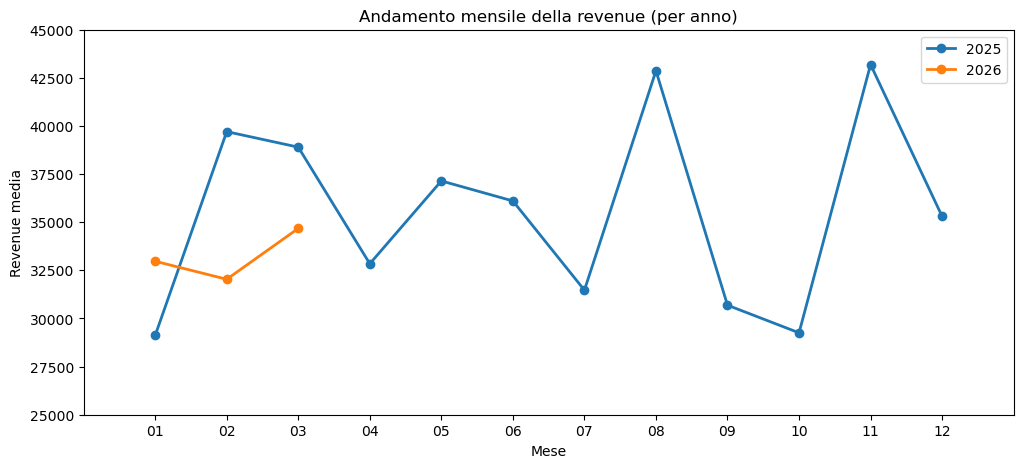

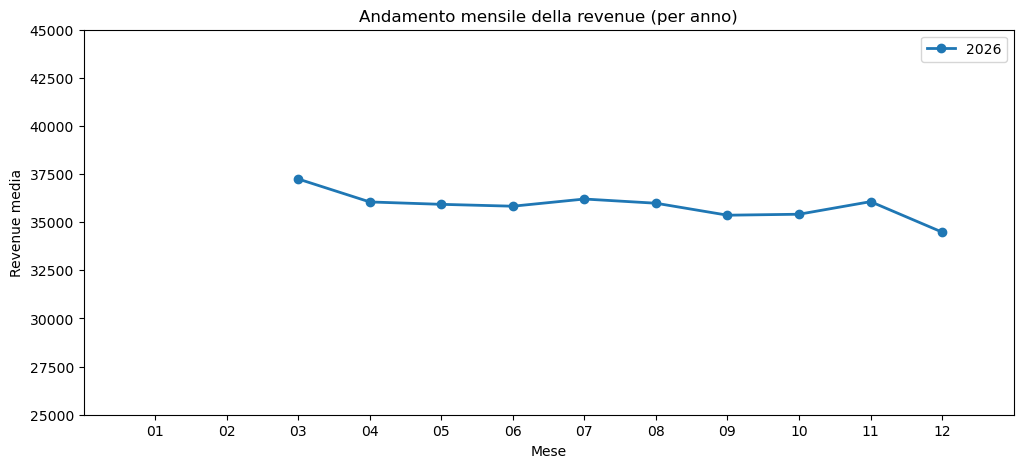

In [8]:
if __name__ == "__main__":
    app = main()